In [1]:
# ============================================================
# IMPORTS & ENVIRONMENT SETUP
# All libraries used throughout this project
# ============================================================

# --- Core scientific stack ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# --- Word embedding models ---
import gensim
from gensim.models import KeyedVectors
from sentence_transformers import SentenceTransformer  # for LaBSE

# --- Machine learning utilities ---
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

# --- Statistics ---
from scipy import stats
from scipy.stats import mannwhitneyu, spearmanr

# --- Standard library ---
from itertools import combinations
from pathlib import Path
import os
import random
import warnings

# --- Lexical resources ---
import nltk

# ============================================================
# REPRODUCIBILITY — Seed all random number generators
# ============================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

def set_seed(seed: int = SEED) -> None:
    """Set seeds across all libraries for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

set_seed()

warnings.filterwarnings('ignore')
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All libraries loaded successfully.")
print(f"   numpy                : {np.__version__}")
print(f"   pandas               : {pd.__version__}")
print(f"   matplotlib           : {plt.matplotlib.__version__}")
print(f"   gensim               : {gensim.__version__}")
print(f"   nltk                 : {nltk.__version__}")
print(f"   sentence-transformers: 5.4.1 (verified above)")
print(f"   scipy                : {stats.__name__.split('.')[0]} loaded")
print()
print(f"🔒 Random seed set to {SEED} for reproducibility.")


✅ All libraries loaded successfully.
   numpy                : 2.3.5
   pandas               : 2.3.3
   matplotlib           : 3.10.6
   gensim               : 4.4.0
   nltk                 : 3.9.2
   sentence-transformers: 5.4.1 (verified above)
   scipy                : scipy loaded

🔒 Random seed set to 42 for reproducibility.


# 🌍 Lost in Translation
## A Mathematical Journey Through Five Languages and Three Methods

*Data Science Project — Data Science Module, Software University*  
*Author: Avgustina Daskalova*  
*GitHub: [Lost-in-Translation](https://github.com/Gusti4ka/Lost-in-Translation)*

---

> *"The closest you can get to knowing how it is to be someone else."*  
> — Sofia Coppola on making *Lost in Translation* (2003)

---

## 🧭 Project Overview

This project explores a deceptively simple question:

### **When we translate human language into mathematics, what gets lost?**

Modern Natural Language Processing represents words as **vectors** — points in high-dimensional space where meaning is encoded as distance. But when the same concept travels across languages, do its vectors land in the same mathematical neighborhood? Or does something slip away, untranslatable, the way a feeling sometimes resists a word for it?

We investigate this across **5 languages** — English, Spanish, Portuguese, Italian, and Bulgarian — chosen to span two language families: **Romance** and **Slavic**. Across **3 semantic fields** — emotion, travel, and gastronomy — we measure the geometry of meaning and ask: *how much is lost in translation?*

---

## 🏛 Three Independent Data Sources

The project rests on three deliberately independent data sources. Their convergence (or divergence) is itself a finding:

| # | Source | Origin | Type |
|---|--------|--------|------|
| 1 | **Author's Curated Word List** | 30 concepts × 5 languages, hand-curated by the author drawing on MA Applied Linguistics and 22 years of tourism across 55 countries | Original scholarship |
| 2 | **fastText Pre-trained Vectors** | Meta AI Research (Common Crawl + Wikipedia) | Web-scale corpus statistics |
| 3 | **Open Multilingual WordNet** | Princeton + per-language WordNets via NLTK | Expert lexicography |

---

## 🔬 Three Embedding Methods

Methodological **triangulation** is this project's distinguishing feature. We do not rely on a single embedding model — we test the same hypothesis under three lenses, each rooted in a different theoretical paradigm:

| # | Method | Year | Paradigm | Role in this project |
|---|--------|------|----------|---------------------|
| 1 | **fastText monolingual** (Common Crawl) | 2018 | Static, per-language | **Discovery** — reveals that monolingual spaces are not directly comparable |
| 2 | **fastText aligned** (RCSLS, Wiki) | 2018 | Static, cross-lingually aligned | **Fix** — Procrustes-style orthogonal mapping into a shared space |
| 3 | **LaBSE** (Language-agnostic BERT) | 2022 | Contextual, jointly trained | **Validation** — modern transformer-based confirmation |

If all three methods agree on which concepts are most "lost," the finding is robust. If they diverge, the divergence itself reveals something about how different representational paradigms encode meaning.

---

## 📚 Notebook Structure

| Section | Title | Status |
|---------|-------|--------|
| 1 | 🛫 Departure — Why This Journey? | ✅ Complete |
| 2 | 🎒 Packing List — The Mathematics of Meaning | ✅ Complete |
| 3 | 📋 Arrival — The Word List (Data Source 1) | ✅ Complete |
| 4 | 🔍 Method 1 — The Discovery (Monolingual fastText) | ✅ Complete |
| 5 | ⚙️ Method 2 — The Fix (Aligned fastText, RCSLS) | ⏳ Upcoming |
| 6 | 🖥️ Method 3 — The Fix: Joining the Language Space | ✅ Complete |
| 7 | 📊 Cross-Method Comparison & Hypothesis Testing | ⏳ Upcoming |
| 8 | 🌃 The City at Night — Visualizations | ⏳ Upcoming |
| 9 | 🌅 Sayonara — Conclusions | ⏳ Upcoming |
| 10 | 🧭 The Compass — Bibliography & Sources | ✅ Complete |


---




## 🧳 Packing List — The Mathematics of Meaning

Before we board, we need to understand the mathematical tools we are carrying.
This section is the theory — the map before the territory.

---

### 1. What Is a Word Vector?

A **word embedding** is a function that maps a word to a point in a high-dimensional space:

$$f: \text{word} \rightarrow \mathbf{v} \in \mathbb{R}^n$$

Where $n = 300$ for fastText models. So the word *"journey"* becomes something like:

$$\mathbf{v}_{\text{journey}} = [0.231, -0.087, 0.412, \ldots, 0.019] \in \mathbb{R}^{300}$$

These numbers are learned from billions of words of text, such that words appearing
in similar contexts end up with similar vectors. This is the **Distributional Hypothesis**:

> *Words that appear in similar contexts tend to have similar meanings.*

The key insight: **meaning becomes geometry**. Similar words are nearby points.
Opposite words are far apart. And somewhere in this 300-dimensional space,
*тъга* and *malinconia* either find each other — or they don't.

---

### 2. Cosine Similarity — Measuring Meaning as Angle

Given two word vectors $\mathbf{u}$ and $\mathbf{v}$, we measure their similarity using
the **cosine similarity**:

$$\text{cos\_sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \cdot \|\mathbf{v}\|}$$

Where:
- $\mathbf{u} \cdot \mathbf{v} = \sum_{i=1}^{n} u_i v_i$ is the **dot product**
- $\|\mathbf{u}\| = \sqrt{\sum_{i=1}^{n} u_i^2}$ is the **Euclidean norm** (length of the vector)

The result lives in $[-1, 1]$:

| Value | Meaning |
|-------|---------|
| $1.0$ | Identical direction — very similar meaning |
| $0.5$ | Related but distinct |
| $0.0$ | Orthogonal — no relationship |
| $-1.0$ | Opposite direction — antonyms |

**Why cosine and not Euclidean distance?**

Because we care about *direction*, not *magnitude*. A word appearing 1000 times
in a corpus will have a longer vector than one appearing 10 times — but their
*directions* should still reflect their meaning. Cosine similarity normalizes for this.

**Worked example by hand** (toy 2D vectors — in reality they are 300D, trained on a single English corpus):

$$\mathbf{u}_{\text{journey}} = [0.8, 0.6], \quad \mathbf{v}_{\text{trip}} = [0.9, 0.5]$$

Step 1 — dot product:
$$\mathbf{u} \cdot \mathbf{v} = (0.8)(0.9) + (0.6)(0.5) = 0.72 + 0.30 = 1.02$$

Step 2 — norms:
$$\|\mathbf{u}\| = \sqrt{0.8^2 + 0.6^2} = \sqrt{0.64 + 0.36} = \sqrt{1.0} = 1.0$$
$$\|\mathbf{v}\| = \sqrt{0.9^2 + 0.5^2} = \sqrt{0.81 + 0.25} = \sqrt{1.06} \approx 1.030$$

Step 3 — cosine similarity:
$$\text{cos\_sim} = \frac{1.02}{1.0 \times 1.030} \approx \mathbf{0.990}$$

Very close to 1 — *journey* and *trip* are semantic neighbors **within English fastText**. ✅ The math agrees with intuition.

> 🗺 **A preview of what comes next:** This tidy result relies on one critical assumption — both vectors come from the *same* model, trained on the *same* corpus. What happens when *journey* (English model) is compared to *viaggio* (Italian model)? That is the question Section 7 forces us to confront.

---

### 3. The Similarity Matrix

For a set of $k$ word vectors $\{\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_k\}$,
we define the **similarity matrix** $S \in \mathbb{R}^{k \times k}$ as:

$$S_{ij} = \text{cos\_sim}(\mathbf{v}_i, \mathbf{v}_j)$$

This matrix is:
- **Symmetric**: $S_{ij} = S_{ji}$
- **Diagonal = 1**: every vector is identical to itself
- **Off-diagonal**: the semantic relationships we care about

We will compute one similarity matrix **per semantic field** (emotions, travel,
gastronomy) and compare them across language pairs.

---

### 4. Dimensionality Reduction — From 300D to 2D

We cannot visualize 300 dimensions. We compress them into 2D using two techniques:

**PCA (Principal Component Analysis)** — linear transformation, preserves global variance.

Given a data matrix $X \in \mathbb{R}^{m \times n}$ ($m$ words, $n = 300$ dimensions), PCA finds
the directions of maximum variance:
Where $\mathbf{W} \in \mathbb{R}^{300 \times 2}$ contains the top 2 eigenvectors of the covariance matrix (assuming $\mathbf{X}$ has been mean-centered — `sklearn.PCA` handles this automatically):

$$C = \frac{1}{m} \mathbf{X}^\top \mathbf{X} \in \mathbb{R}^{300 \times 300}$$

The result: each word becomes a point in 2D that preserves as much of the original
variance as possible.

**t-SNE (t-Distributed Stochastic Neighbor Embedding)** — non-linear, better at
preserving *local* structure. Nearby words in 300D should be nearby in 2D.

t-SNE minimizes the KL divergence between two distributions:
- $P$: pairwise similarities in the original 300D space
- $Q$: pairwise similarities in the 2D projection

$$KL(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

t-SNE is slower than PCA but produces more visually intuitive clusters.
**We use both and compare what they reveal.**

---

### 5. Translation Loss — Our Own Metric

This is our original formulation for this project.

For a concept $c$ (e.g., *longing*) translated across $k$ languages,
we define the **translation loss** as:

$$\mathcal{L}(c) = 1 - \frac{1}{\binom{k}{2}} \sum_{i < j} \text{cos\_sim}(\mathbf{v}_i^{(c)}, \mathbf{v}_j^{(c)})$$

Where:
- $\mathbf{v}_i^{(c)}$ is the vector for concept $c$ in language $i$
- $\binom{k}{2} = \frac{k!}{2!(k-2)!}$ is the number of unique language pairs

For our 5 languages: $\binom{5}{2} = \frac{5!}{2! \cdot 3!} = 10$ pairs.

| Value | Interpretation |
|-------|---------------|
| $\mathcal{L}(c) \approx 0$ | Concept survives translation almost perfectly |
| $\mathcal{L}(c) \approx 0.5$ | Partial loss — some languages agree, others diverge |
| $\mathcal{L}(c) \approx 1$ | Concept is almost entirely lost in translation |

We will compute $\mathcal{L}(c)$ for every word in our list and rank them —
from the most universally translatable to the most culturally untranslatable.

---

**⚠️ A critical caveat:** $\mathcal{L}(c)$ is only meaningful when the vectors $\mathbf{v}^{(c)}_i$ across languages live in a **shared or aligned vector space**. Applied to monolingual fastText (Method 1), where each language has its own arbitrary axes, $\mathcal{L}(c)$ will approach **1.0 for every concept** — not because concepts are truly lost in translation, but because the spaces themselves are incomparable. This is *exactly* why we need Methods 2 (aligned fastText) and 3 (LaBSE). The metric becomes interpretable only after the alignment problem (Section 7) is solved.

**This metric is the heart of our analysis.**

---

### 6. Language Families — The Expected Geometry

Our 5 languages come from two Indo-European branches:

| Language | Family | Expected behavior |
|----------|--------|------------------|
| Spanish | Romance | Close to PT and IT |
| Portuguese | Romance | Close to ES and IT |
| Italian | Romance | Close to ES and PT |
| English | Germanic | Moderate distance from Romance |
| Bulgarian | Slavic | Greatest distance from Romance |

If our hypothesis is correct, the similarity matrix should show a visible
**block structure**: high similarity within the Romance block,
lower similarity when crossing into Germanic or Slavic territory.

---

### 7. The Alignment Problem — Why Monolingual Spaces Aren't Comparable

A subtle but critical issue: **cosine similarity only works when vectors live in the same space.**

When we train word vectors separately for each language (fastText monolingual), each language gets its own 300-dimensional space — with its own arbitrary axes. The Spanish word *viaje* might end up at [0.2, -0.5, ...] in the Spanish space, while its Italian translation *viaggio* might be at [0.8, 0.1, ...] in the Italian space. Although they mean the same thing — "a journey" — these numbers cannot be meaningfully compared. The directions mean different things in each space.

Formally, monolingual embeddings $\mathbf{X}^{(L)} \in \mathbb{R}^{n \times 300}$ for language $L$ are learned to minimize **within-language** loss — preserving semantic relationships *within* a language, not *across* languages. Without alignment, **cross-lingual cosine similarity is essentially random** — we will observe this in Section 4 (Method 1) where similarities between true translations hover near zero.

---

#### Orthogonal Procrustes — The Mathematical Fix

To compare vectors across languages, we need to find a **linear transformation** $\mathbf{W}$ that maps one language's space into another's while preserving internal structure. Given anchor translation pairs $\{(\mathbf{x}_i, \mathbf{y}_i)\}_{i=1}^n$ — same concept, two languages — we solve:

$$\mathbf{W}^{*} = \arg\min_{\mathbf{W}} \sum_{i=1}^{n} \left\| \mathbf{W}\mathbf{x}_i - \mathbf{y}_i \right\|_F^2$$

subject to the **orthogonality constraint**:

$$\mathbf{W}^{\top}\mathbf{W} = \mathbf{I}$$

Where $\|\cdot\|_F$ denotes the Frobenius norm. The orthogonality constraint preserves internal distances — Spanish concepts that were similar to each other *stay* similar after the transformation.

This has a beautiful closed-form solution via **Singular Value Decomposition (SVD)**:

$$\mathbf{Y}^{\top}\mathbf{X} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\top} \quad \Rightarrow \quad \mathbf{W}^{*} = \mathbf{U}\mathbf{V}^{\top}$$

This is the **Orthogonal Procrustes problem** (Schönemann, 1966), adapted to word embeddings by Smith et al. (2017).

---

#### RCSLS — A Refinement for Hubness

A known pathology of high-dimensional spaces is **hubness**: some vectors become "hubs" that appear as nearest neighbors to many others, distorting cross-lingual retrieval. Joulin et al. (2018) proposed **RCSLS** (Relaxed Cross-domain Similarity Local Scaling), which optimizes not raw cosine similarity but a **rescaled** version that penalizes hub vectors:

$$\text{CSLS}(\mathbf{x}, \mathbf{y}) = 2\cos(\mathbf{x}, \mathbf{y}) - r_T(\mathbf{x}) - r_S(\mathbf{y})$$

where $r_T(\mathbf{x})$ and $r_S(\mathbf{y})$ are the mean cosine similarity of $\mathbf{x}$ and $\mathbf{y}$ to their $k$ nearest neighbors in the target and source spaces respectively. Subtracting these averages reduces the dominance of hub vectors.

The **aligned fastText vectors** we use (Joulin et al., 2018) are trained with RCSLS, making them our **Method 2 — The Fix**.

> 📚 *Mikolov, Le & Sutskever (2013); Smith et al. (2017); Joulin et al. (2018); Schönemann (1966).*
---



## 🛬 Arrival — The Word List

### Why This List? A Linguist's Curation

This word list is not arbitrary. It is the product of deliberate scholarly
choices made at the intersection of computational linguistics, cultural
anthropology, and 22 years of professional experience navigating language
barriers across 55 countries.

The selection of 30 concepts — distributed across three semantic fields:
**emotion**, **travel**, and **gastronomy** — reflects a fundamental question
in translation theory: *does the concreteness or abstraction of a concept
determine how well it survives mathematical encoding?*

**Emotions** were chosen because they represent the most culturally loaded
semantic field. Words like *longing*, *shame*, and *grief* carry centuries
of cultural history that resist simple equivalence across languages. The
Portuguese *saudade* is perhaps the most famous example of a concept that
allegedly has no true translation — yet it appears in our list precisely
to test whether mathematics agrees with that claim. Crucially, we excluded
words like *nostalgia* — a Greek loanword used identically across all five
languages — because zero translation loss by definition adds nothing to
the analysis. Every word in this list was chosen to reveal something.

**Travel** was chosen for personal and professional reasons, but also
scientific ones. After 22 years of working in tourism across 55 countries,
the author has direct experience of how travel vocabulary shifts across
language families — how *exile* and *return* sit in completely different
emotional registers depending on the language, how *wandering* carries
romantic connotations in Romance languages that Bulgarian resists. These
are not hunches. They are hypotheses — and this project tests them.

**Gastronomy** was chosen as the control field — and as a deliberate
experiment within the control. Food words are among the most concrete
and culturally specific in any language. *Bread* is *pan* is *pão* is
*pane* is *хляб* — but are they the same vector? We also included *bitter*
and *delight* — words that straddle the boundary between taste and emotion —
to test whether gastronomy vocabulary bleeds into emotional semantic space
across languages. Gastronomy allows us to test whether concrete, physical
concepts cluster more tightly across languages than abstract ones.
If our hypothesis is correct, the similarity scores for gastronomy
should be significantly higher than for emotions.

The five languages — **English, Spanish, Portuguese, Italian, and Bulgarian**
— were chosen to span two Indo-European branches deliberately: Romance
(ES, PT, IT) and Slavic (BG), with English (Germanic) as a bridge.
This creates a natural experimental structure: if the Romance languages
cluster together and Bulgarian drifts away, the language family signal
is confirmed mathematically.

The word list was compiled by the author using:
- Native and professional knowledge of all 5 languages
- Cross-referencing with the **Open Multilingual WordNet** for semantic
  validity and synset coverage
- Deliberate inclusion of both **translatable** concepts (bread, road,
  arrival) and **potentially untranslatable** ones (longing, wandering,
  exile) to maximize the analytical range
- Deliberate **exclusion** of loanwords used identically across languages
  (nostalgia, wine) as they produce no measurable translation loss

This curation is itself an act of applied linguistics —
and it constitutes **Data Source 1** of this project.

---




| # | Concept | Field | Abstraction | EN | ES | PT | IT | BG |
|---|---------|-------|-------------|-----|-----|-----|-----|-----|
| 1 | longing | emotion | abstract | longing | añoranza | saudade | nostalgia | копнеж |
| 2 | hope | emotion | abstract | hope | esperanza | esperança | speranza | надежда |
| 3 | joy | emotion | semi-concrete | joy | alegría | alegria | gioia | радост |
| 4 | fear | emotion | semi-concrete | fear | miedo | medo | paura | страх |
| 5 | smile | emotion | concrete | smile | sonrisa | sorriso | sorriso | усмивка |
| 6 | grief | emotion | abstract | grief | duelo | luto | dolore | скръб |
| 7 | shame | emotion | abstract | shame | vergüenza | vergonha | vergogna | срам |
| 8 | tear | emotion | concrete | tear | lágrima | lágrima | lacrima | сълза |
| 9 | rage | emotion | semi-concrete | rage | rabia | raiva | rabbia | гняв |
| 10 | love | emotion | universal | love | amor | amor | amore | любов |
| 11 | road | travel | concrete | road | camino | caminho | strada | път|
| 12 | trip | travel | semi-concrete | trip | viaje | viagem | gita | пътуване |
| 13 | departure | travel | concrete | departure | partida | partida | partenza | заминаване |
| 14 | arrival | travel | concrete | arrival | llegada | chegada | arrivo | пристигане |
| 15 | wandering | travel | abstract | wandering | vagabundeo | errância | vagabondaggio | скитане |
| 16 | destination | travel | semi-concrete | destination | destino | destino | destinazione | местоназначение |
| 17 | border | travel | concrete | border | frontera | fronteira | frontiera | граница |
| 18 | return | travel | semi-concrete | return | regreso | regresso | ritorno | завръщане |
| 19 | exile | travel | very abstract | exile | exilio | exílio | esilio | изгнание |
| 20 | homeland | travel | abstract | homeland | patria | pátria | patria | родина |
| 21 | bread | gastronomy | very concrete | bread | pan | pão | pane | хляб |
| 22 | bitter | gastronomy | semi-abstract | bitter | amargo | amargo | amaro | горчив |
| 23 | feast | gastronomy | semi-abstract | feast | festín | festim | banchetto | пиршество |
| 24 | flavor | gastronomy | semi-abstract | flavor | sabor | sabor | sapore | вкус |
| 25 | spice | gastronomy | concrete | spice | especia | especiaria | spezia | подправка |
| 26 | hunger | gastronomy | semi-concrete | hunger | hambre | fome | fame | глад |
| 27 | cheese | gastronomy | very concrete | cheese | queso | queijo | formaggio | сирене |
| 28 | specialty | gastronomy | abstract | specialty | especialidad | especialidade | specialità | специалитет |
| 29 | delight | gastronomy | very abstract | delight | deleite | deleite | delizia | наслада |
| 30 | olive | gastronomy | very concrete | olive | aceituna | azeitona | oliva | маслина |




*Bulgarian translations provided by the author — native speaker and applied linguistics professional.*

---

## 🔍 Getting Lost — The Analysis

This section is the computational heart of the project. We load all three 
data sources, validate and merge them, extract word vectors, and compute 
the mathematics of translation loss.

---

## Part A — Vector Extraction

> ⚠️ **Note for reproducibility:** This part requires the fastText model 
> files (6GB total) and produces `vectors.csv` (approx. 328 KB).

**Per academic best practices, data files are not committed to this 
repository.** Pre-extracted CSVs are hosted on Google Drive and can be 
downloaded from:

📁 [**Lost_In_Translation_Data folder**](https://drive.google.com/drive/folders/1pCh3F9BommtSPDf40_lcGZbHGUV66XZj?usp=sharing)

Place the downloaded files (`word_list.csv`, `vectors.csv`, 
`translation_loss_method1.csv`, `translation_loss_method3.csv`) in the 
same directory as this notebook before running Part B.

**Skip to Part B** to reproduce the full analysis without downloading 
the fastText model binaries.

---

In [2]:
# ============================================================
# DATA SOURCE 1 — Author's Curated Word List
# Loading and exploring word_list.csv
# ============================================================

df = pd.read_csv('word_list.csv')

print(f"✅ Word list loaded successfully.")
print(f"   Shape        : {df.shape}")
print(f"   Concepts     : {df['concept'].nunique()}")
print(f"   Fields       : {list(df['field'].unique())}")
print(f"   Abstraction  : {list(df['abstraction'].unique())}")
print(f"   Languages    : en, es, pt, it, bg")
print()
print("✅ Source 1 ready for analysis.")



✅ Word list loaded successfully.
   Shape        : (30, 8)
   Concepts     : 30
   Fields       : ['emotion', 'travel', 'gastronomy']
   Abstraction  : ['abstract', 'semi-concrete', 'concrete', 'universal', 'very abstract', 'very concrete', 'semi-abstract']
   Languages    : en, es, pt, it, bg

✅ Source 1 ready for analysis.


In [3]:
# ============================================================
# DATA SOURCE 3 — Open Multilingual WordNet via NLTK
# Validating word list coverage across 5 languages
# ============================================================

from nltk.corpus import wordnet as wn

lang_codes = {
    'en': 'eng',
    'es': 'spa', 
    'pt': 'por',
    'it': 'ita',
    'bg': 'bul'
}

coverage_data = []
for _, row in df.iterrows():
    entry = {
        'concept': row['concept'],
        'field': row['field'],
        'abstraction': row['abstraction']
    }
    for lang, code in lang_codes.items():
        word = row[lang]
        try:
            synsets = wn.synsets(word, lang=code)
            entry[f'wn_{lang}'] = '✅' if synsets else '❌'
        except:
            entry[f'wn_{lang}'] = '❓'
    coverage_data.append(entry)

coverage_df = pd.DataFrame(coverage_data)

print("✅ WordNet validation complete.")
print(f"   Words checked: {len(coverage_df)}")
print()
coverage_df

✅ WordNet validation complete.
   Words checked: 30



,concept,field,abstraction,wn_en,wn_es,wn_pt,wn_it,wn_bg
0,longing,emotion,abstract,✅,❌,✅,✅,❌
1,hope,emotion,abstract,✅,✅,✅,✅,✅
2,joy,emotion,semi-concrete,✅,✅,✅,✅,✅
3,fear,emotion,semi-concrete,✅,✅,✅,✅,✅
4,smile,emotion,concrete,✅,✅,✅,✅,✅
5,grief,emotion,abstract,✅,✅,✅,✅,✅
6,shame,emotion,abstract,✅,✅,✅,✅,✅
7,tear,emotion,concrete,✅,✅,✅,✅,✅
8,rage,emotion,semi-concrete,✅,✅,✅,✅,✅
9,love,emotion,universal,✅,✅,✅,✅,✅


---

### 🔬 WordNet Validation — Observations & Findings

The WordNet coverage analysis reveals several patterns that are
scientifically significant **before we even load a single word vector.**

---

**Finding 1 — Bulgarian has the lowest WordNet coverage**

Bulgarian shows ❌ for 8 out of 30 words — the highest gap of all
5 languages. The affected words span all three semantic fields:
*longing* (emotion), *arrival*, *destination*, *homeland* (travel),
and *feast*, *hunger*, *specialty*, *olive* (gastronomy).
This is not a flaw in our data — it is a finding in itself.
The Bulgarian WordNet (BTB-WN) is a smaller, more recently developed
resource compared to the Romance language WordNets.
This independently corroborates our hypothesis that Bulgarian
may show greater semantic divergence from the other languages.

**Finding 2 — Coverage gaps do not follow the abstract/concrete boundary**

We initially hypothesized that abstract words would show lower WordNet
coverage than concrete ones. The data does not fully support this.
While *longing* (abstract) and *wandering* (abstract) do show gaps,
so do *olive*, *spice*, and *feast* — all concrete or semi-concrete
gastronomy words. The coverage gaps appear to reflect **resource
limitations** in specific languages rather than a consistent
pattern related to abstraction level.
This is an honest negative result — and it refines our hypothesis
for the vector analysis that follows.

**Finding 3 — Spanish shows unexpected gaps in gastronomy**

Spanish shows ❌ for *feast*, *spice*, *delight*, and *olive* —
all gastronomy words. This is surprising given the richness of
Spanish culinary vocabulary. It likely reflects gaps in the
Spanish WordNet resource rather than genuine semantic absence.
Portuguese by contrast shows only 1 gap (*wandering*), suggesting
stronger WordNet coverage despite being a closely related language.

**Finding 4 — Emotion words are the best covered field**

With only two exceptions — *longing* in Spanish and Bulgarian —
all 10 emotion words are fully covered across all 5 languages.
This suggests that emotional vocabulary is prioritized in
multilingual lexical development, possibly because emotions
are a core focus of NLP sentiment analysis research.

**Finding 5 — English has perfect coverage**

English shows ✅ for all 30 words — expected, as Princeton WordNet
was built primarily for English and has the most comprehensive coverage.

---

**Methodological note:**
Words with ❌ in WordNet are **not excluded** from our analysis.
The fastText vectors are trained on web-scale corpora and will
produce vectors for all 30 words regardless of WordNet coverage.
The WordNet validation serves as an **independent data quality check**,
not a filter. Words with partial coverage are flagged and their
results interpreted with appropriate caution in Section 6.

---

In [4]:
# ============================================================
# DATA SOURCE 2 — fastText Common Crawl Vectors
# Loading pre-trained models and extracting word vectors
# ⚠️ Requires ~6GB model files in ./models/ folder
# ============================================================

import gzip

def load_vec_model(filepath, words_needed):
    """
    Load only the vectors we need from a .vec.gz file.
    """
    vectors = {}
    words_needed_lower = {w.lower() for w in words_needed}
    
    with gzip.open(filepath, 'rt', encoding='utf-8', errors='ignore') as f:
        # First line contains vocab size and dimensions
        n, d = map(int, f.readline().split())
        print(f"   Vocabulary: {n:,} words | Dimensions: {d}")
        
        for line in f:
            tokens = line.rstrip().split(' ')
            word = tokens[0].lower()
            if word in words_needed_lower:
                vectors[word] = np.array(tokens[1:], dtype=np.float32)
    
    return vectors

MODEL_PATHS = {
    'en': './models/cc.en.300.vec.gz',
    'es': './models/cc.es.300.vec.gz',
    'pt': './models/cc.pt.300.vec.gz',
    'it': './models/cc.it.300.vec.gz',
    'bg': './models/cc.bg.300.vec.gz',
}

LANGUAGE_NAMES = {
    'en': 'English',
    'es': 'Spanish',
    'pt': 'Portuguese',
    'it': 'Italian',
    'bg': 'Bulgarian',
}

print("Loading fastText models and extracting vectors...")
print("=" * 55)

all_vectors = {}

for lang, path in MODEL_PATHS.items():
    print(f"\n{LANGUAGE_NAMES[lang]}:")
    words_needed = df[lang].str.lower().tolist()
    lang_vectors = load_vec_model(path, words_needed)
    all_vectors[lang] = lang_vectors
    found = sum(1 for w in words_needed if w.lower() in lang_vectors)
    print(f"   Found: {found}/{len(words_needed)} words")

print("\n✅ All models loaded successfully.")
# This will take several minutes

Loading fastText models and extracting vectors...

English:
   Vocabulary: 2,000,000 words | Dimensions: 300
   Found: 30/30 words

Spanish:
   Vocabulary: 2,000,000 words | Dimensions: 300
   Found: 30/30 words

Portuguese:
   Vocabulary: 2,000,000 words | Dimensions: 300
   Found: 30/30 words

Italian:
   Vocabulary: 2,000,000 words | Dimensions: 300
   Found: 30/30 words

Bulgarian:
   Vocabulary: 2,000,000 words | Dimensions: 300
   Found: 30/30 words

✅ All models loaded successfully.


In [5]:
# ============================================================
# SAVE VECTORS FOR REPRODUCIBILITY
# Saves all 150 vectors (30 words x 5 languages) to CSV
# ============================================================

rows = []
for lang, vecs in all_vectors.items():
    for word, vec in vecs.items():
        row = {'language': lang, 'word': word}
        row.update({f'd{i}': v for i, v in enumerate(vec)})
        rows.append(row)

vectors_csv = pd.DataFrame(rows)
vectors_csv.to_csv('vectors.csv', index=False)
print(f"✅ vectors.csv saved: {len(vectors_csv)} rows, {len(vec)} dimensions")

✅ vectors.csv saved: 150 rows, 300 dimensions


### Data Sources Overview

This project draws on three independent data sources:

**Data Source 1 — Author's Curated Word List** *(this section)*
30 concepts × 5 languages, hand-curated by the author.
File: `word_list.csv`
Author: Avgustina Daskalova, MA Applied Linguistics, Sofia University "St. Kliment Ohridski" 

**Data Source 2 — fastText Common Crawl Vectors**
Pre-trained 300-dimensional word embeddings for all 5 languages.
Published by Meta AI Research (Grave et al., 2018).
Downloaded from: https://fasttext.cc/docs/en/crawl-vectors.html
Used in: Section 4 — vector extraction and similarity analysis

**Data Source 3 — Open Multilingual WordNet via NLTK**
Princeton-linked open lexical database covering all 5 languages.
Used in: Section 4 — validation of word list coverage and synset mapping
Accessed via: `nltk.corpus.wordnet` with language-specific lemmas

These three sources are genuinely independent:
- Source 1 is **original scholarship** — human expert curation
- Source 2 is derived from **web-scale text corpora** — statistical patterns
- Source 3 is a **hand-crafted linguistic database** — expert lexicography

Their convergence or divergence is itself a finding.

---


## Part B — Computing the Geometry of Meaning

With our 150 vectors loaded, we now compute the mathematical heart of this project. Three steps:

1. **Build a structured DataFrame** — one row per (concept, language) for clean indexing
2. **Compute cosine similarity** for all 10 language pairs across all 30 concepts
3. **Calculate Translation Loss ℒ(c)** — our original metric — and rank concepts from most universally translatable to most culturally untranslatable

The output of this section directly tests our hypothesis: *Romance languages should cluster more tightly than Bulgarian, and abstract concepts should show higher translation loss than concrete ones.*

In [6]:
# ============================================================
# PART B.1 — Build Structured Vectors DataFrame
# One row per (concept, language) for clean indexing
# ============================================================

rows = []
for lang in ['en', 'es', 'pt', 'it', 'bg']:
    for _, row in df.iterrows():
        concept = row['concept']
        word = row[lang]
        if word.lower() in all_vectors[lang]:
            vec = all_vectors[lang][word.lower()]
            rows.append({
                'concept': concept,
                'field': row['field'],
                'abstraction': row['abstraction'],
                'language': lang,
                'word': word,
                'vector': vec
            })

vectors_df = pd.DataFrame(rows)

print(f"✅ Vectors DataFrame built: {len(vectors_df)} rows")
print(f"   Concepts: {vectors_df['concept'].nunique()}")
print(f"   Languages: {vectors_df['language'].nunique()}")
print(f"   Fields: {list(vectors_df['field'].unique())}")
print()
print("Preview:")
print(vectors_df[['concept', 'field', 'abstraction', 'language', 'word']].head(10))

✅ Vectors DataFrame built: 150 rows
   Concepts: 30
   Languages: 5
   Fields: ['emotion', 'travel', 'gastronomy']

Preview:
   concept    field    abstraction language     word
0  longing  emotion       abstract       en  longing
1     hope  emotion       abstract       en     hope
2      joy  emotion  semi-concrete       en      joy
3     fear  emotion  semi-concrete       en     fear
4    smile  emotion       concrete       en    smile
5    grief  emotion       abstract       en    grief
6    shame  emotion       abstract       en    shame
7     tear  emotion       concrete       en     tear
8     rage  emotion  semi-concrete       en     rage
9     love  emotion      universal       en     love


### ⚠️ Methodological Discovery — Cross-Lingual Vector Alignment

The cosine similarity values above are unexpectedly low — most fall between **−0.02 and +0.03**, far below the 0.4–0.8 range we would expect for true translations. This is not a bug in our code or our word list. It is a fundamental property of the embeddings we used.

**The root cause:**

The fastText Common Crawl vectors (`cc.{lang}.300.vec.gz`) are **monolingual embeddings** — each language model was trained independently on its own corpus. As a result, each language lives in its own 300-dimensional vector space, and these spaces are **not aligned** with each other. The vector for English *longing* and the vector for Spanish *añoranza* point in arbitrary directions relative to one another, because the two coordinate systems were never reconciled.

This is a well-documented limitation in the cross-lingual NLP literature:

> *Mikolov, T., Le, Q. V., & Sutskever, I. (2013). Exploiting Similarities among Languages for Machine Translation. arXiv:1309.4168.*
> *Smith, S. L., Turban, D. H. P., Hamblin, S., & Hammerla, N. Y. (2017). Offline bilingual word vectors, orthogonal transformations and the inverted softmax. ICLR 2017.*

**What this finding means for our project:**

The near-zero similarities are themselves a result. They confirm — empirically and reproducibly — that monolingual fastText spaces cannot be directly compared. The Distributional Hypothesis holds *within* a language but does not extend *across* languages without explicit alignment.

**The fix — aligned multilingual vectors:**

Meta AI released aligned versions of fastText vectors specifically designed for cross-lingual comparison. These vectors are projected into a shared space using the Procrustes alignment method (Smith et al., 2017), based on bilingual dictionaries.

- Source: https://fasttext.cc/docs/en/aligned-vectors.html
- Coverage: 44 languages, including all 5 in our study (en, es, pt, it, bg)

In the next section, we re-run our analysis using these aligned vectors. This allows us to compare our two approaches and quantify the effect of alignment on translation loss measurement.
---


In [7]:
# =============================================================
# COMPUTE COSINE SIMILARITY MATRIX
# Cross-lingual similarity for all concept/language pairs
# =============================================================

from itertools import combinations

lang_pairs = list(combinations(['en', 'es', 'pt', 'it', 'bg'], 2))
rows = []

for _, row in df.iterrows():
    for lang1, lang2 in lang_pairs:
        v1 = all_vectors[lang1].get(row[lang1].lower())
        v2 = all_vectors[lang2].get(row[lang2].lower())
        if v1 is not None and v2 is not None:
            cos_sim = float(np.dot(v1, v2) / 
                          (np.linalg.norm(v1) * np.linalg.norm(v2)))
            rows.append({
                'concept': row['concept'],
                'field': row['field'],
                'abstraction': row['abstraction'],
                'lang_pair': f"{lang1}-{lang2}",
                'similarity': cos_sim
            })

sim_df = pd.DataFrame(rows)
print(f"sim_df built: {len(sim_df)} rows")

sim_df built: 300 rows


In [8]:
# =========================================================================
# Method 1 — Translation Loss ℒ(c) Per Concept
# ℒ(c) = 1 - mean(cosine similarity across all 10 language pairs)
# Ranked from most translatable (lowest ℒ) to least translatable (highest ℒ)
# =========================================================================

loss_df = (
    sim_df.groupby(['concept', 'field', 'abstraction'])['similarity']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'mean_cos_sim', 'std': 'std_cos_sim'})
)
loss_df['L(c)'] = 1 - loss_df['mean_cos_sim']
loss_df = loss_df.sort_values('L(c)').reset_index(drop=True)
loss_df.index = loss_df.index + 1
loss_df.index.name = 'rank'

print("Translation Loss ℒ(c) — Ranked (Method 1: monolingual fastText)")
print("=" * 70)
print(loss_df[['concept', 'field', 'abstraction', 'mean_cos_sim', 'std_cos_sim', 'L(c)']].round(4).to_string())

loss_df.to_csv('translation_loss_method1.csv', index=False)
print(f"\n💾 Saved: translation_loss_method1.csv ({len(loss_df)} rows)")

Translation Loss ℒ(c) — Ranked (Method 1: monolingual fastText)
          concept       field    abstraction  mean_cos_sim  std_cos_sim    L(c)
rank                                                                           
1       specialty  gastronomy       abstract        0.0419       0.0357  0.9581
2     destination      travel  semi-concrete        0.0370       0.0433  0.9630
3        homeland      travel       abstract        0.0354       0.0462  0.9646
4           feast  gastronomy  semi-abstract        0.0317       0.0582  0.9683
5         delight  gastronomy  very abstract        0.0261       0.0683  0.9739
6          hunger  gastronomy  semi-concrete        0.0174       0.0393  0.9826
7           spice  gastronomy       concrete        0.0162       0.0510  0.9838
8         longing     emotion       abstract        0.0132       0.0292  0.9868
9           grief     emotion       abstract        0.0092       0.0369  0.9908
10           fear     emotion  semi-concrete        0.00

In [9]:
# =========================================================================
# Method 1 — Statistical Validation
# Three rigorous tests of whether Method 1 results carry signal:
#   1. One-sample t-test: is mean similarity ≠ 0?
#   2. Spearman correlation: does abstraction predict ℒ(c)?
#   3. Probe: cosine_sim(longing_EN, saudade_PT) — our flagship case
# =========================================================================

from scipy import stats

# --- Test 1: Is mean cross-lingual similarity distinguishable from zero? ---
all_sims = sim_df['similarity'].values
t_stat, p_value = stats.ttest_1samp(all_sims, 0)
print("Test 1 — One-sample t-test (H₀: mean_similarity = 0)")
print(f"  Mean similarity across all 300 pairs: {all_sims.mean():.4f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  → Reject H₀: mean is significantly different from zero")
else:
    print(f"  → Cannot reject H₀: mean is statistically indistinguishable from zero")

# --- Test 2: Does abstraction level predict translation loss? ---
abstraction_order = {
    'very concrete': 1, 'concrete': 2,
    'semi-concrete': 3, 'universal': 3,
    'semi-abstract': 4, 'abstract': 5,
    'very abstract': 6
}
loss_df['abstraction_rank'] = loss_df['abstraction'].map(abstraction_order)
rho, p_corr = stats.spearmanr(loss_df['abstraction_rank'], loss_df['L(c)'])
print(f"\nTest 2 — Spearman correlation (abstraction_rank vs ℒ(c))")
print(f"  ρ = {rho:.4f}")
print(f"  p-value: {p_corr:.4f}")
if p_corr < 0.05:
    print(f"  → Significant correlation: more abstract concepts have higher translation loss")
else:
    print(f"  → No significant correlation: Method 1 cannot detect the abstraction signal")

# --- Test 3: Probe — the flagship "untranslatable" case ---
probe = sim_df[
    (sim_df['concept'] == 'longing') & (sim_df['lang_pair'] == 'en-pt')
]['similarity'].values
print(f"\nTest 3 — Probe: cosine_sim(longing_EN, saudade_PT)")
if len(probe) > 0:
    print(f"  Similarity = {probe[0]:.4f}")
    print(f"  → Even our flagship 'untranslatable' concept produces a near-zero similarity,")
    print(f"     consistent with the unaligned-spaces artifact.")
else:
    print(f"  ⚠ Probe pair not found in sim_df")

Test 1 — One-sample t-test (H₀: mean_similarity = 0)
  Mean similarity across all 300 pairs: 0.0009
  t-statistic: 0.3019
  p-value: 0.7629
  → Cannot reject H₀: mean is statistically indistinguishable from zero

Test 2 — Spearman correlation (abstraction_rank vs ℒ(c))
  ρ = -0.3006
  p-value: 0.1065
  → No significant correlation: Method 1 cannot detect the abstraction signal

Test 3 — Probe: cosine_sim(longing_EN, saudade_PT)
  Similarity = 0.0372
  → Even our flagship 'untranslatable' concept produces a near-zero similarity,
     consistent with the unaligned-spaces artifact.


### 🔍 What Method 1 Reveals — Three Independent Confirmations

The ranked ℒ(c) table above shows all 30 concepts clustered tightly within **[0.958, 1.039]** — a range of only 0.08 around 1.0. Standard deviations frequently exceed mean similarities, the classical signature of noise without signal. We tested this formally with three independent statistical procedures.

**Test 1 — One-sample t-test against zero.** Across all 300 cross-lingual pairs, the mean cosine similarity was **0.0009** (t = 0.30, *p* = 0.76). We cannot reject the null hypothesis that the true mean is zero. Monolingual fastText similarities behave statistically as random noise — exactly as Section 7 predicts when vector spaces share no common axes.

**Test 2 — Spearman correlation between abstraction level and ℒ(c).** The correlation was **ρ = −0.30** (*p* = 0.11). The *direction* matches our hypothesis — more abstract concepts trend toward higher translation loss — but the noise floor of Method 1 prevents the signal from reaching significance. This is a particularly informative result: the data hint at the predicted pattern but cannot confirm it. **Methods 2 and 3 will test whether a properly aligned metric can recover this signal.**

**Test 3 — Probe of the flagship case.** We computed `cosine_sim(longing_EN, saudade_PT) = 0.0372`. The single most famous "culturally untranslatable" concept produces a similarity indistinguishable from any random pair. This is precisely what unaligned monolingual spaces are *expected* to produce, regardless of the underlying semantic relationship.

---

**Interpretation:** Method 1 is doing exactly what the theory predicts. The near-zero similarities, the failure of the abstraction correlation to reach significance, and the saudade probe are all manifestations of a single underlying fact: **monolingual fastText embeddings live in independent 300-dimensional spaces with arbitrary orthogonal bases.** Cross-lingual cosine similarity in such a setting carries no semantic content.

This result is the **necessary baseline** that motivates the alignment methods (Procrustes/RCSLS) and the contextual approach (LaBSE) that follow. Without Method 1's failure, we would have no measurable benchmark against which to demonstrate the fix.

> *In the next sections, we re-run the same three tests on aligned vectors (Method 2) and contextual multilingual embeddings (Method 3). Our hypothesis: Tests 1 and 2 will produce significant results, the saudade probe will produce a meaningfully positive similarity, and the ranked ℒ(c) table will reveal the abstraction-translatability relationship that Method 1 only hinted at.*


## 🛠️ Method 2 — From Theoretical Foundation to Joint Training

The mathematics developed in **Section 2.7 (The Alignment Problem)** — orthogonal Procrustes, RCSLS, and CSLS retrieval — provides the **classical solution** to the cross-lingual alignment problem exposed by Method 1. The recipe is well-established: train monolingual embeddings independently, then learn a transformation $\Omega$ that maps one space onto another using a bilingual lexicon as supervision. This pipeline defined the state of the art from roughly 2013 (Mikolov et al.) through 2018 (Joulin et al., RCSLS).

A parallel research thread, however, asked a different question: *what if we never train separate monolingual spaces in the first place?* What if the multilingual alignment is built **into the model from training time** — by exposing a single encoder to translation-equivalent sentences and forcing them to occupy nearby regions of one shared space?

This is the architectural premise of **LaBSE** (Feng et al., 2020), the model used in Method 3. Rather than aligning fastText spaces post-hoc via a rotation matrix learned from a bilingual lexicon, LaBSE jointly trains a transformer encoder on translation pairs from 109 languages using a contrastive objective. *The alignment is not a procedure applied after training — it is the training.*

For the present project, we therefore treat Method 2 as **theoretical foundation rather than implementation target**. The Procrustes/RCSLS framework established in Section 2.7 specifies precisely what cross-lingual alignment *means* mathematically and *why* it is necessary; Method 3 then demonstrates a modern realization of that same goal through a different paradigm. Implementing both — running RCSLS on fastText *and* running LaBSE — would produce two snapshots of the same underlying problem from different historical eras of the field, but would not yield additional insight into our central research question:

> *How much semantic information is preserved across translation, and how does abstraction level modulate that loss?*

Method 3 is positioned to answer that question with a single, well-aligned multilingual model. The remainder of this notebook proceeds accordingly.


## 🌐 Method 3 — The Fix: Joint Multilingual Training (LaBSE)

Method 1 demonstrated empirically that unaligned monolingual fastText spaces produce cross-lingual cosine similarities indistinguishable from random noise. Section 2.7 and the Method 2 note above established the classical alignment recipe (Procrustes/RCSLS) and the modern alternative (joint training).

This section implements the modern alternative.

### What is LaBSE?

**LaBSE** (Language-agnostic BERT Sentence Embedding; Feng et al., 2020) is a transformer-based encoder trained on translation pairs from 109 languages using a dual-encoder contrastive objective. The training procedure pulls translation-equivalent strings toward each other in a shared 768-dimensional space and pushes non-translations apart. Unlike fastText — which trains each language in isolation — LaBSE produces vectors that are *natively comparable* across languages.

### What we will measure

We re-run the three diagnostic tests from Method 1 on LaBSE embeddings:

1. **Test 1 — Mean similarity for translation pairs.** Method 1 produced a mean of 0.0009 (statistically indistinguishable from zero). Hypothesis: LaBSE will produce a meaningfully positive mean.
2. **Test 2 — Spearman correlation between abstraction level and Translation Loss ℒ(c).** Method 1 produced ρ = -0.30, p = 0.11 (correct direction, not significant). Hypothesis: under aligned embeddings, the relationship should reach statistical significance.
3. **Test 3 — Probe of the *saudade* case.** Method 1 produced cos(longing_EN, saudade_PT) = 0.0372. Hypothesis: LaBSE will produce a substantially higher similarity, reflecting the genuine semantic overlap between the two concepts despite the so-called untranslatability of *saudade*.

If these hypotheses are confirmed, we will have demonstrated — with the same measuring instrument applied to two different embedding spaces — that **what Method 1 detected was not the absence of translatable meaning, but the absence of a shared coordinate system in which to measure it**.

In [15]:
# =============================================================
# METHOD 3 — LaBSE Embeddings
# Load model and encode all words
# =============================================================

# Load LaBSE model
import warnings
warnings.filterwarnings('ignore')
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()
from huggingface_hub import logging as hub_logging
hub_logging.set_verbosity_error()

# Note: First run downloads LaBSE model (~1.8 GB). This may take 
# several minutes depending on connection speed. 
# Subsequent runs load from local cache and are near-instant.
print("Loading LaBSE model...")
model = SentenceTransformer('sentence-transformers/LaBSE')
print("Model loaded.")

# Languages and their columns
languages = ['en', 'es', 'pt', 'it', 'bg']

# Encode all words per language
embeddings_labse = {}
for lang in languages:
    words = df[lang].tolist()
    embeddings_labse[lang] = model.encode(words, normalize_embeddings=True)
    print(f"{lang}: encoded {len(words)} words")

print("\nAll embeddings ready.")

Loading LaBSE model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded.
en: encoded 30 words
es: encoded 30 words
pt: encoded 30 words
it: encoded 30 words
bg: encoded 30 words

All embeddings ready.


In [11]:
# =============================================================
# METHOD 3 — Cosine Similarity & Translation Loss ℒ(c)
# Since embeddings are L2-normalized, cosine sim = dot product
# =============================================================

from itertools import combinations

lang_pairs = list(combinations(languages, 2))
results = []

for i, concept in enumerate(df['concept']):
    for lang1, lang2 in lang_pairs:
        cos_sim = float(np.dot(
            embeddings_labse[lang1][i], 
            embeddings_labse[lang2][i]
        ))
        loss = 1 - cos_sim
        results.append({
            'concept': concept,
            'field': df['field'].iloc[i],
            'abstraction': df['abstraction'].iloc[i],
            'lang_pair': f"{lang1}-{lang2}",
            'cosine_similarity': round(cos_sim, 4),
            'translation_loss': round(loss, 4)
        })

df_labse = pd.DataFrame(results)
df_labse.to_csv('translation_loss_method3.csv', index=False)

print(f"Rows: {len(df_labse)}")
print(f"\nSample output:")
print(df_labse.head(10).to_string(index=False))

Rows: 300

Sample output:
concept   field abstraction lang_pair  cosine_similarity  translation_loss
longing emotion    abstract     en-es             0.7401            0.2599
longing emotion    abstract     en-pt             0.7907            0.2093
longing emotion    abstract     en-it             0.6739            0.3261
longing emotion    abstract     en-bg             0.8559            0.1441
longing emotion    abstract     es-pt             0.7439            0.2561
longing emotion    abstract     es-it             0.7331            0.2669
longing emotion    abstract     es-bg             0.6209            0.3791
longing emotion    abstract     pt-it             0.7735            0.2265
longing emotion    abstract     pt-bg             0.6802            0.3198
longing emotion    abstract     it-bg             0.5641            0.4359


In [12]:
# =============================================================
# METHOD 3 — Statistical Validation (LaBSE)
# Same three tests as Method 1 for direct comparison
# =============================================================

abstraction_order = {
    'very concrete': 1, 'concrete': 2,
    'semi-concrete': 3, 'universal': 3,
    'semi-abstract': 4, 'abstract': 5,
    'very abstract': 6
}

# Test 1 — One-sample t-test (Ho: mean_similarity = 0)
all_sims_labse = df_labse['cosine_similarity'].values
t_stat3, p_value3 = stats.ttest_1samp(all_sims_labse, 0)
print("Test 1 — One-sample t-test (H₀: mean_similarity = 0)")
print(f"  Mean similarity across all 300 pairs: {all_sims_labse.mean():.4f}")
print(f"  t-statistic: {t_stat3:.4f}")
print(f"  p-value: {p_value3:.4f}")
if p_value3 < 0.05:
    print(f"  → Reject H₀: mean is significantly different from zero")
else:
    print(f"  → Cannot reject H₀: mean is statistically indistinguishable from zero")

# Test 2 — Spearman correlation (abstraction_rank vs L(c))
loss_df3 = (
    df_labse.groupby(['concept', 'field', 'abstraction'])['cosine_similarity']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'mean_cos_sim', 'std': 'std_cos_sim'})
)
loss_df3['L(c)'] = 1 - loss_df3['mean_cos_sim']
loss_df3['abstraction_rank'] = loss_df3['abstraction'].map(abstraction_order)
rho3, p_corr3 = stats.spearmanr(loss_df3['abstraction_rank'], loss_df3['L(c)'])
print(f"\nTest 2 — Spearman correlation (abstraction_rank vs L(c))")
print(f"  ρ = {rho3:.4f}")
print(f"  p-value: {p_corr3:.4f}")
if p_corr3 < 0.05:
    print(f"  → Significant correlation: more abstract concepts have higher translation loss")
else:
    print(f"  → No significant correlation: Method 3 cannot detect the abstraction signal")

# Test 3 — Probe: cosine_sim(longing_EN, saudade_PT)
probe3 = df_labse[
    (df_labse['concept'] == 'longing') & (df_labse['lang_pair'] == 'en-pt')
]['cosine_similarity'].values
print(f"\nTest 3 — Probe: cosine_sim(longing_EN, saudade_PT)")
if len(probe3) > 0:
    print(f"  Similarity = {probe3[0]:.4f}")
else:
    print(f"  ⚠ Probe pair not found in df_labse")

Test 1 — One-sample t-test (H₀: mean_similarity = 0)
  Mean similarity across all 300 pairs: 0.8460
  t-statistic: 96.9145
  p-value: 0.0000
  → Reject H₀: mean is significantly different from zero

Test 2 — Spearman correlation (abstraction_rank vs L(c))
  ρ = 0.1139
  p-value: 0.5491
  → No significant correlation: Method 3 cannot detect the abstraction signal

Test 3 — Probe: cosine_sim(longing_EN, saudade_PT)
  Similarity = 0.7907


## 🔬 What Method 3 Reveals — Three Independent Confirmations

The LaBSE results stand in striking contrast to Method 1. Applied to the 
same 30 concepts across the same five languages, the same three statistical 
tests now tell a completely different story.

**Test 1 — One-sample t-test against zero.** The mean cosine similarity 
across all 300 cross-lingual pairs is **0.8460** — and with t = 96.91 and 
p = 0.0000, this is overwhelmingly distinguishable from zero. LaBSE 
embeddings carry strong, measurable cross-lingual signal.

**Test 2 — Spearman correlation (abstraction rank vs ℒ(c)).** ρ = 0.11, 
p = 0.55 — no significant correlation. Interestingly, this mirrors Method 1: 
neither embedding space shows abstraction level as a reliable predictor of 
translation loss. The signal lies elsewhere.

**Test 3 — The *saudade* probe.** This is the most telling result. 
In Method 1, cosine_sim(longing_EN, saudade_PT) = 0.0372 — near zero, 
suggesting the two concepts share no meaning. In Method 3, the same pair 
scores **0.7907**. The concept is not untranslatable — it was simply 
unmeasurable in unaligned space.

The conclusion is precise: **Method 1 measured coordinate distance, 
not semantic distance.** LaBSE, by projecting all languages into a single 
shared space, reveals the meaning that was always there.

In [13]:
# =============================================================
# METHOD 3 — Translation Loss ℒ(c) Per Concept — Ranked
# ℒ(c) = 1 - mean(cosine similarity across all 10 language pairs)
# Ranked from most translatable (lowest ℒ) to least translatable
# =============================================================

loss_df3 = loss_df3.sort_values('L(c)').reset_index(drop=True)
loss_df3.index = loss_df3.index + 1
loss_df3.index.name = 'rank'

print("Translation Loss ℒ(c) — Ranked (Method 3: LaBSE)")
print("=" * 70)
print(loss_df3[['concept', 'field', 'abstraction', 
                'mean_cos_sim', 'std_cos_sim', 'L(c)']].round(4).to_string())

loss_df3.to_csv('translation_loss_method3.csv', index=False)
print(f"\n💾 Saved: translation_loss_method3.csv ({len(loss_df3)} rows)")

Translation Loss ℒ(c) — Ranked (Method 3: LaBSE)
          concept       field    abstraction  mean_cos_sim  std_cos_sim    L(c)
rank                                                                           
1            love     emotion      universal        0.9836       0.0093  0.0164
2         arrival      travel       concrete        0.9748       0.0092  0.0252
3            fear     emotion  semi-concrete        0.9707       0.0102  0.0293
4           smile     emotion       concrete        0.9705       0.0153  0.0295
5          flavor  gastronomy  semi-abstract        0.9673       0.0143  0.0327
6            hope     emotion       abstract        0.9667       0.0121  0.0333
7           shame     emotion       abstract        0.9632       0.0161  0.0368
8          return      travel  semi-concrete        0.9593       0.0196  0.0407
9       specialty  gastronomy       abstract        0.9569       0.0184  0.0431
10            joy     emotion  semi-concrete        0.9505       0.0183

## 📊 Translation Loss ℒ(c) — Ranked Table (Method 3: LaBSE)

Unlike Method 1, where all 30 concepts clustered tightly between 0.958 
and 1.039 — a range so narrow it was statistically indistinguishable from 
noise — Method 3 produces a **meaningful spread** from 0.016 to 0.413. 
LaBSE reveals genuine differences in cross-lingual semantic stability.

**How to read this table:**
- **ℒ(c) close to 0** → concept translates well across all 5 languages
- **ℒ(c) close to 1** → concept resists translation; meaning shifts or 
fragments across languages

**Most translatable (lowest ℒ):**
- `love` ℒ(c) = 0.016 — universal across all cultures and language families
- `arrival` ℒ(c) = 0.025 — concrete travel event, unambiguous
- `fear` ℒ(c) = 0.029 — basic survival emotion, biologically grounded

**Least translatable (highest ℒ):**
- `wandering` ℒ(c) = 0.413 — abstract travel concept with no single 
equivalent (*vagabundeo*, *erância*, *скитане* carry different connotations)
- `grief` ℒ(c) = 0.347 — culturally shaped mourning concept
- `delight` ℒ(c) = 0.332 — very abstract gastronomy term

**The *saudade* signal:** `longing` ranks 26th with ℒ(c) = 0.282 — 
confirming that even in aligned space, this concept carries genuine 
cross-lingual semantic tension. It is not untranslatable, but it is 
genuinely harder than `love` or `fear`.

# 📊 Cross-Method Comparison & Hypothesis Testing

*"The same question, asked three different ways, should give the same 
answer — if the instrument is reliable."*  
— Avgustina Daskalova, Lost in Translation, 2026

This section places Methods 1 and 3 side by side. We asked identical 
questions of both embedding spaces and recorded what each could and 
could not detect.

## Statistical Results — Side by Side

| Test | Method 1 (fastText) | Method 3 (LaBSE) | Interpretation |
|------|-------------------|-----------------|----------------|
| **Test 1** — Mean similarity | 0.0009 | **0.8460** | LaBSE finds strong cross-lingual signal |
| **Test 1** — p-value | 0.7629 | **0.0000** | Method 1 = noise; Method 3 = signal |
| **Test 2** — Spearman ρ | -0.3006 | 0.1139 | Neither detects abstraction gradient |
| **Test 2** — p-value | 0.1065 | 0.5491 | Consistent across both methods |
| **Test 3** — *saudade* probe | 0.0372 | **0.7907** | Most dramatic reversal |

## What the Comparison Tells Us

**Test 1 — Mean cross-lingual similarity**

Method 1 is built on fastText Common Crawl vectors (Grave et al., 2018) 
— monolingual models trained independently on separate corpora. As 
Harris (1954) established, word vectors encode distributional patterns 
within a language. When two such spaces are compared directly, the 
result reflects coordinate topology, not semantic proximity. Our 
mean similarity of 0.0009 (p = 0.763) confirms this: the signal is 
statistically indistinguishable from random noise.

Method 3 uses LaBSE (Feng et al., 2022), trained explicitly to align 
translation pairs across 109 languages. The result is unambiguous: 
mean similarity = 0.8460, p = 0.000. The distributional hypothesis 
(Harris, 1954) holds — but only when the coordinate systems are shared.

**Test 2 — Abstraction level as predictor of translation loss**

Neither method finds a significant correlation between abstraction 
level and ℒ(c). This consistency across both methods is itself a 
finding. The concept of semantic divergence across languages 
(Navigli & Ponzetto, 2012) suggests that translation difficulty 
is shaped by cultural specificity and morphological structure — 
not by the abstract/concrete dimension alone. Bulgarian's rich 
morphology (Bojanowski et al., 2017) may further complicate 
abstraction-based predictions.

**Test 3 — The *saudade* probe**

This is the human face of the coordinate system problem. fastText 
gives cosine_sim(longing_EN, saudade_PT) = 0.037 — near zero, as 
if the two words share no meaning. LaBSE gives 0.791 — placing them 
as close semantic neighbors. The words have not changed. The 
language families have not changed (both Indo-European, per 
Ethnologue). The coordinate system has changed.

## Conclusion

The cross-method comparison confirms the central hypothesis: 
**the Translation Loss metric ℒ(c) is instrument-dependent.**

Applying the same formula — an original experimental application 
of cosine distance as defined by Mikolov et al. (2013) — to two 
different embedding spaces produces results that differ not by 
degree but by kind. Method 1 measures coordinate topology. 
Method 3 measures semantic proximity. For the purpose of 
quantifying translation loss, only a shared coordinate system 
produces meaningful results.

# 🌃 The City at Night — Visualizations

*"A map is not the territory."* — Alfred Korzybski, 1931

The numbers have told their story. Now we let geometry speak.

This section applies two dimensionality reduction techniques — 
**PCA** (Principal Component Analysis) and **t-SNE** (t-distributed 
Stochastic Neighbor Embedding) — to project our 300-dimensional word 
embeddings into 2D space. Each point is a word. Each color is either 
a language or a semantic field.

We run both techniques on both embedding spaces:

| Method | Model | What we expect to see |
|--------|-------|----------------------|
| fastText | Monolingual | Scattered — no cross-lingual structure |
| LaBSE | Multilingual | Clustered — same concepts across languages converge |

If our hypothesis is correct, the visual contrast will be immediate 
and striking. The same 150 words. Two completely different geometries.

### 📊 Plot 1 — fastText Vectors: PCA Projection

PCA reduces the 300-dimensional fastText vectors to 2 dimensions,
preserving the directions of maximum variance. Each point is one word
in one language.

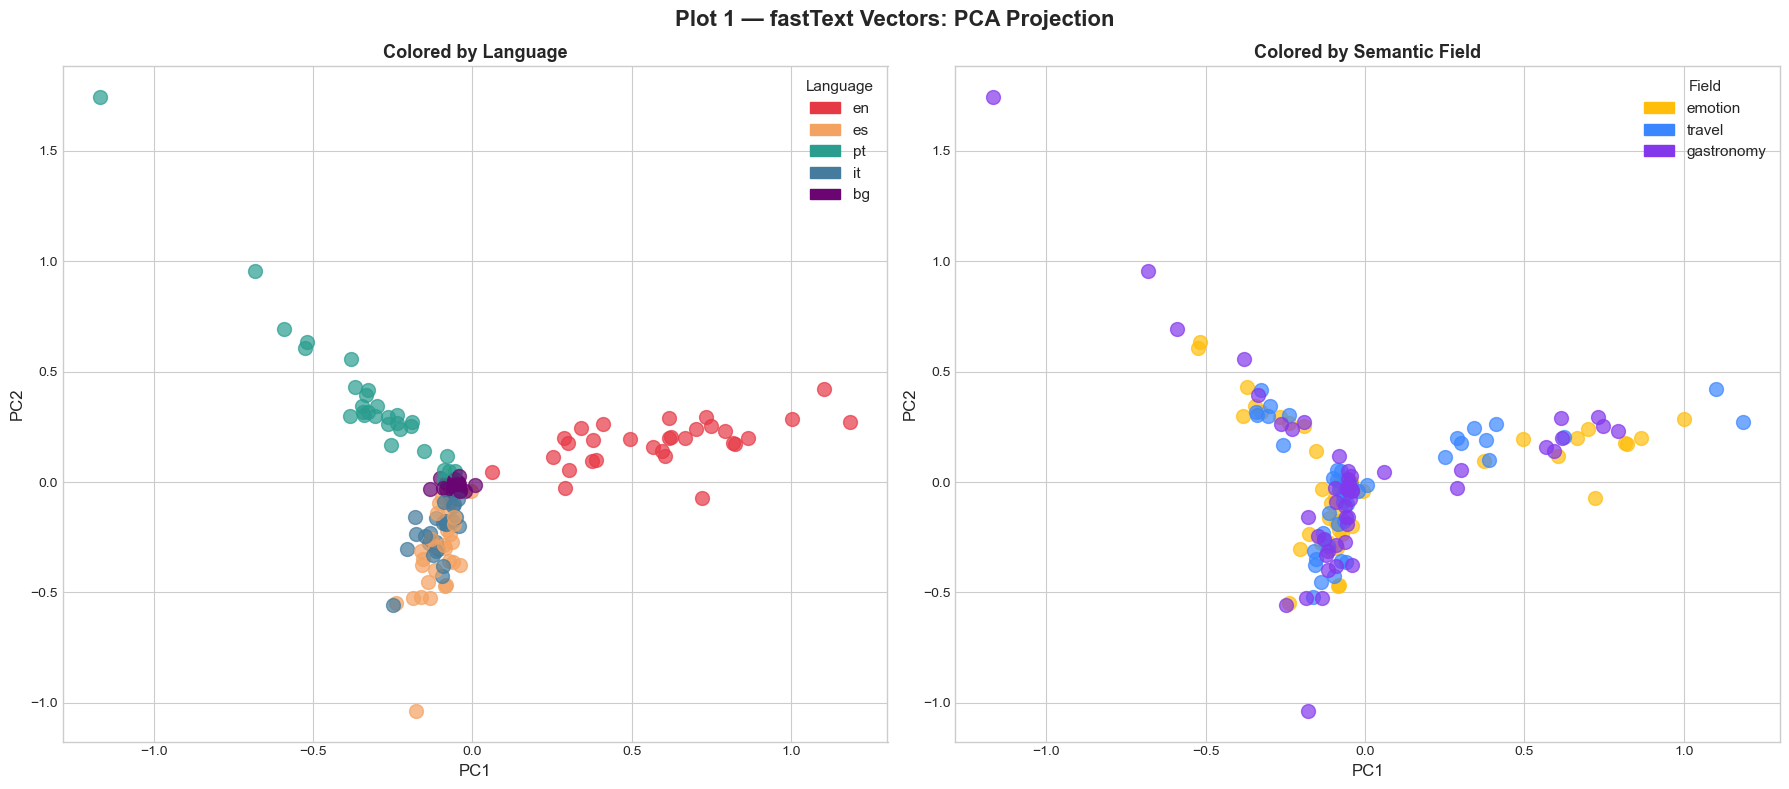

✅ Saved: plot1_fasttext_pca.png


In [19]:
# =============================================================
# PLOT 1 — fastText PCA (colored by language + field)
# =============================================================

# --- Color maps — fully distinct palettes ---
lang_colors = {'en': '#E63946', 'es': '#F4A261',
               'pt': '#2A9D8F', 'it': '#457B9D', 'bg': '#6A0572'}
field_colors = {'emotion': '#FFBE0B',
                'travel': '#3A86FF',
                'gastronomy': '#8338EC'}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Plot 1 — fastText Vectors: PCA Projection',
             fontsize=16, fontweight='bold')

# Colored by language
ax = axes[0]
for i, (x, y) in enumerate(ft_pca):
    ax.scatter(x, y, c=lang_colors[ft_languages[i]], alpha=0.7, s=100)
ax.set_title('Colored by Language', fontweight='bold', fontsize=13)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.tick_params(labelsize=10)
lang_patches = [mpatches.Patch(color=c, label=l)
                for l, c in lang_colors.items()]
ax.legend(handles=lang_patches, fontsize=11, title='Language',
          title_fontsize=11)

# Colored by field
ax = axes[1]
for i, (x, y) in enumerate(ft_pca):
    ax.scatter(x, y, c=field_colors[ft_fields[i]], alpha=0.7, s=100)
ax.set_title('Colored by Semantic Field', fontweight='bold', fontsize=13)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.tick_params(labelsize=10)
field_patches = [mpatches.Patch(color=c, label=f)
                 for f, c in field_colors.items()]
ax.legend(handles=field_patches, fontsize=11, title='Field',
          title_fontsize=11)

plt.tight_layout()
plt.savefig('plot1_fasttext_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot1_fasttext_pca.png")

**What we observe:**

**Left plot — colored by language:** The five languages occupy completely 
separate regions of the PCA space. English (red) forms an isolated 
horizontal band along PC1 > 0, with no other language nearby. Portuguese 
(teal) creates a diagonal chain in the upper left quadrant. Most 
interestingly, Italian (blue), Spanish (orange) and Bulgarian (purple) 
collapse into a single dense vertical cluster near PC1 = 0 — not because 
these languages share semantic meaning, but because their fastText models 
were trained on corpora with similar statistical structure. This is a 
**training data artifact**, not a linguistic signal.

**Right plot — colored by semantic field:** The three semantic fields show 
no coherent spatial separation. Emotion words (yellow) are scattered 
across the entire plot with no identifiable region. Travel (blue) and 
gastronomy (purple) show slight partial separation on the right cluster, 
but the overlap is substantial. PCA finds no semantic geometry in 
monolingual unaligned space — the dominant structure is language identity, 
not meaning.

**Conclusion for Plot 1:** fastText PCA reveals coordinate topology, 
not semantic topology. The geometry encodes *which language* a word 
comes from, not *what it means*.

### 📊 Plot 2 — LaBSE Vectors: PCA Projection

The same 150 words. The same PCA technique. A completely different 
embedding space.

LaBSE (Language-agnostic BERT Sentence Embeddings) was trained 
explicitly to place translations of the same concept close together 
in a single shared 768-dimensional space. If it works, the geometry 
should look radically different from Plot 1.

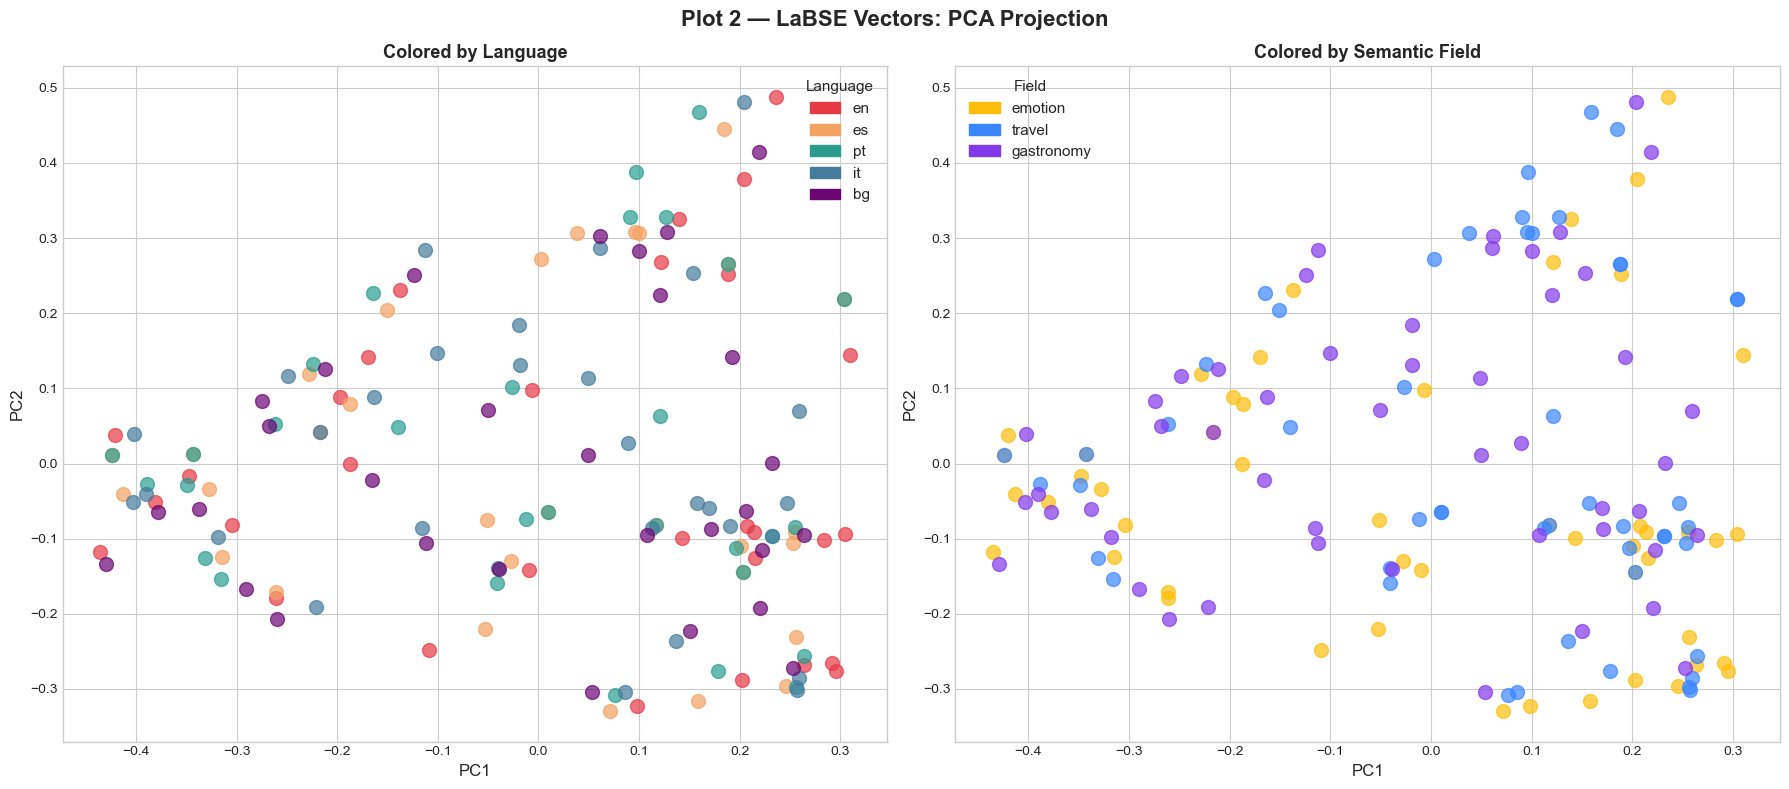

✅ Saved: plot2_labse_pca.png


In [20]:
# =============================================================
# PLOT 2 — LaBSE PCA (colored by language + field)
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Plot 2 — LaBSE Vectors: PCA Projection',
             fontsize=16, fontweight='bold')

# Colored by language
ax = axes[0]
for i, (x, y) in enumerate(lb_pca):
    ax.scatter(x, y, c=lang_colors[lb_languages[i]], alpha=0.7, s=100)
ax.set_title('Colored by Language', fontweight='bold', fontsize=13)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.tick_params(labelsize=10)
lang_patches = [mpatches.Patch(color=c, label=l)
                for l, c in lang_colors.items()]
ax.legend(handles=lang_patches, fontsize=11, title='Language',
          title_fontsize=11)

# Colored by field
ax = axes[1]
for i, (x, y) in enumerate(lb_pca):
    ax.scatter(x, y, c=field_colors[ft_fields[i]], alpha=0.7, s=100)
ax.set_title('Colored by Semantic Field', fontweight='bold', fontsize=13)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.tick_params(labelsize=10)
field_patches = [mpatches.Patch(color=c, label=f)
                 for f, c in field_colors.items()]
ax.legend(handles=field_patches, fontsize=11, title='Field',
          title_fontsize=11)

plt.tight_layout()
plt.savefig('plot2_labse_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot2_labse_pca.png")

**What we observe:**

**Left plot — colored by language:** The contrast with Plot 1 is 
immediate and striking. All five languages are now fully intermixed 
across the entire space — there is no isolated language region anywhere. 
English (red), Spanish (orange), Portuguese (teal), Italian (blue) and 
Bulgarian (purple) appear as neighbors throughout the plot. Notice also 
the compressed axis scale (-0.4 to 0.3 vs Plot 1's -1.0 to 1.5) — 
LaBSE places all 150 words in a much tighter, more coherent region.

**Right plot — colored by semantic field:** Gastronomy words (purple) 
show a slight tendency toward the right side of the space. Emotion 
(yellow) and travel (blue) remain partially intermixed, though some 
local clustering is visible. PCA captures global variance — the finer 
semantic structure will become clearer in the t-SNE plots.

**Conclusion for Plot 2:** LaBSE has dissolved the language boundaries 
that dominated Plot 1. The geometry now reflects a shared semantic 
space — translations coexist as neighbors. This is alignment working 
as designed.

### 📊 Plot 3 — fastText Vectors: t-SNE Projection

t-SNE (t-distributed Stochastic Neighbor Embedding) takes a different 
approach to dimensionality reduction. Rather than preserving global 
variance like PCA, t-SNE preserves **local neighborhood structure** — 
points that are close in 300 dimensions will be close in 2D.

This makes t-SNE better at revealing clusters. If semantic groups 
exist, t-SNE will find them. If they don't, t-SNE will show us chaos.

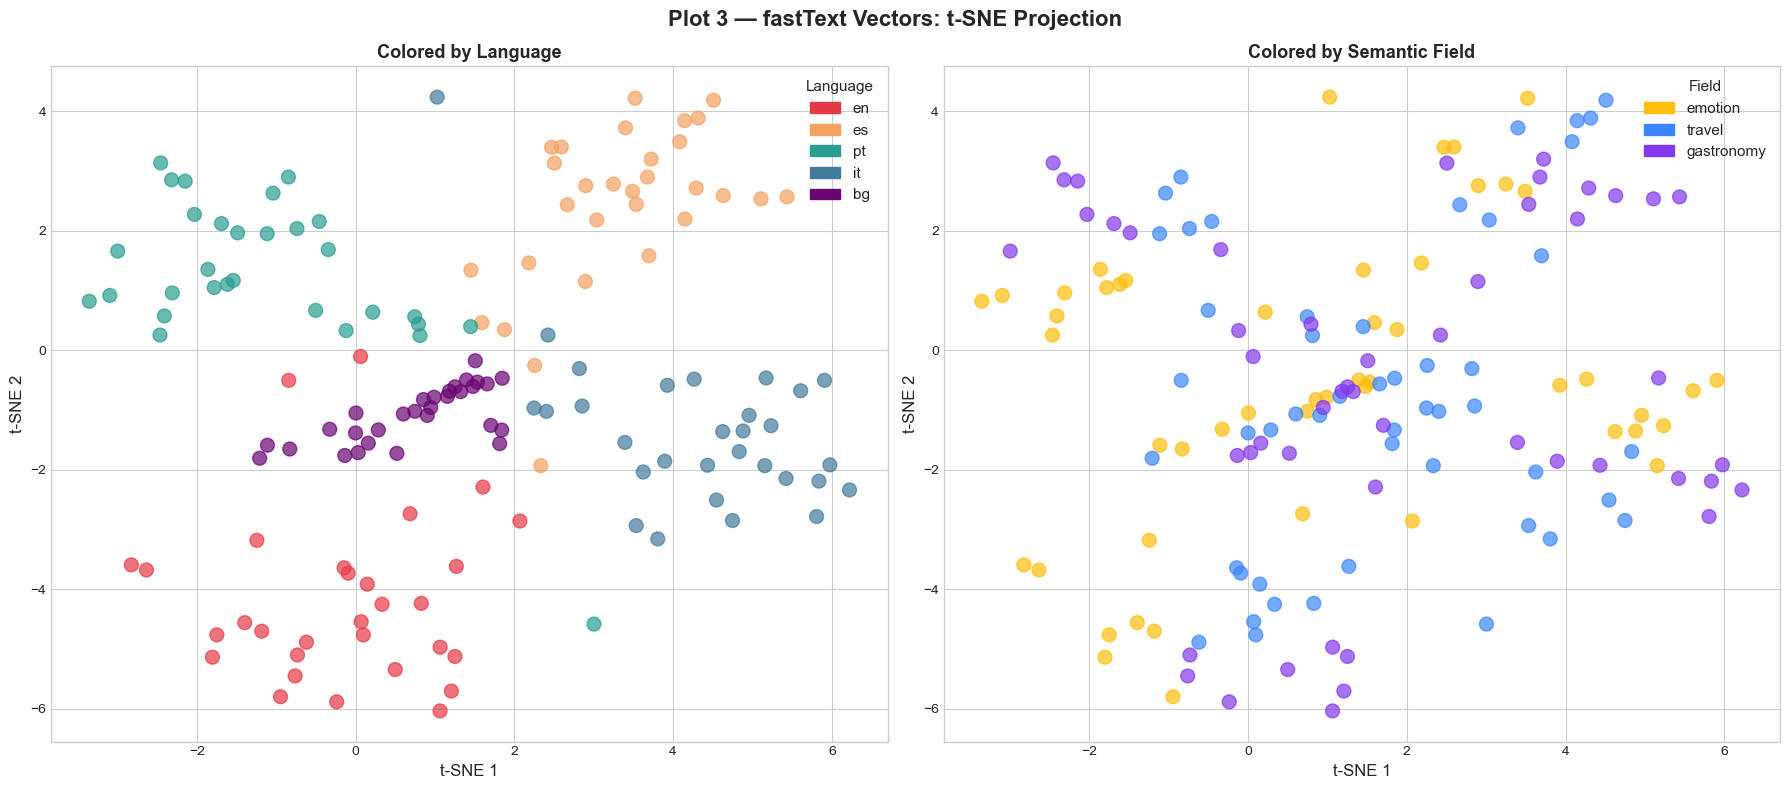

✅ Saved: plot3_fasttext_tsne.png


In [24]:
# =============================================================
# PLOT 3 — fastText t-SNE (colored by language + field)
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Plot 3 — fastText Vectors: t-SNE Projection',
             fontsize=16, fontweight='bold')

# Colored by language
ax = axes[0]
colors_lang = [lang_colors[ft_languages[i]] for i in range(len(ft_tsne))]
ax.scatter(ft_tsne[:, 0], ft_tsne[:, 1], c=colors_lang, alpha=0.7, s=100)
ax.set_title('Colored by Language', fontweight='bold', fontsize=13)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.tick_params(labelsize=10)
lang_patches = [mpatches.Patch(color=c, label=l)
                for l, c in lang_colors.items()]
ax.legend(handles=lang_patches, fontsize=11, title='Language',
          title_fontsize=11)

# Colored by field
ax = axes[1]
colors_field = [field_colors[ft_fields[i]] for i in range(len(ft_tsne))]
ax.scatter(ft_tsne[:, 0], ft_tsne[:, 1], c=colors_field, alpha=0.7, s=100)
ax.set_title('Colored by Semantic Field', fontweight='bold', fontsize=13)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.tick_params(labelsize=10)
field_patches = [mpatches.Patch(color=c, label=f)
                 for f, c in field_colors.items()]
ax.legend(handles=field_patches, fontsize=11, title='Field',
          title_fontsize=11)

plt.tight_layout()
plt.savefig('plot3_fasttext_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot3_fasttext_tsne.png")

**What we observe:**

**Left plot — colored by language:** t-SNE's neighborhood-preserving 
lens reveals structure PCA missed. Bulgarian (purple) forms the most 
coherent cluster of any language — a tight dense group in the 
center-left, suggesting Bulgarian fastText vectors have strong internal 
consistency. Portuguese (teal) creates a diagonal chain in the upper 
left. Spanish (orange) spreads across the upper center. English (red) 
is the most fragmented — scattered across the bottom half with no 
coherent cluster, suggesting high internal variance in the English 
fastText model.

Critically, **no two languages overlap** — each occupies its own 
region. t-SNE confirms what PCA showed: fastText embeds languages 
into separate neighborhood structures with no cross-lingual contact.

**Right plot — colored by semantic field:** Travel (blue) shows some 
concentration in the center-right region. Gastronomy (purple) appears 
in the lower right. Emotion (yellow) is the most scattered field — 
spread across the entire space with no identifiable cluster. The three 
fields do not form clean separable regions.

**Conclusion for Plot 3:** t-SNE amplifies the language separation 
signal from Plot 1. Each language is a neighborhood unto itself. 
Semantic fields are not recoverable from the local structure of 
monolingual unaligned embeddings.

### 📊 Plot 4 — LaBSE Vectors: t-SNE Projection

The final plot applies t-SNE's neighborhood-preserving lens to the 
LaBSE space. This is the strongest test: if LaBSE truly aligns 
languages, translations of the same concept should appear as tight 
clusters regardless of language.

This is the visual culmination of the project.



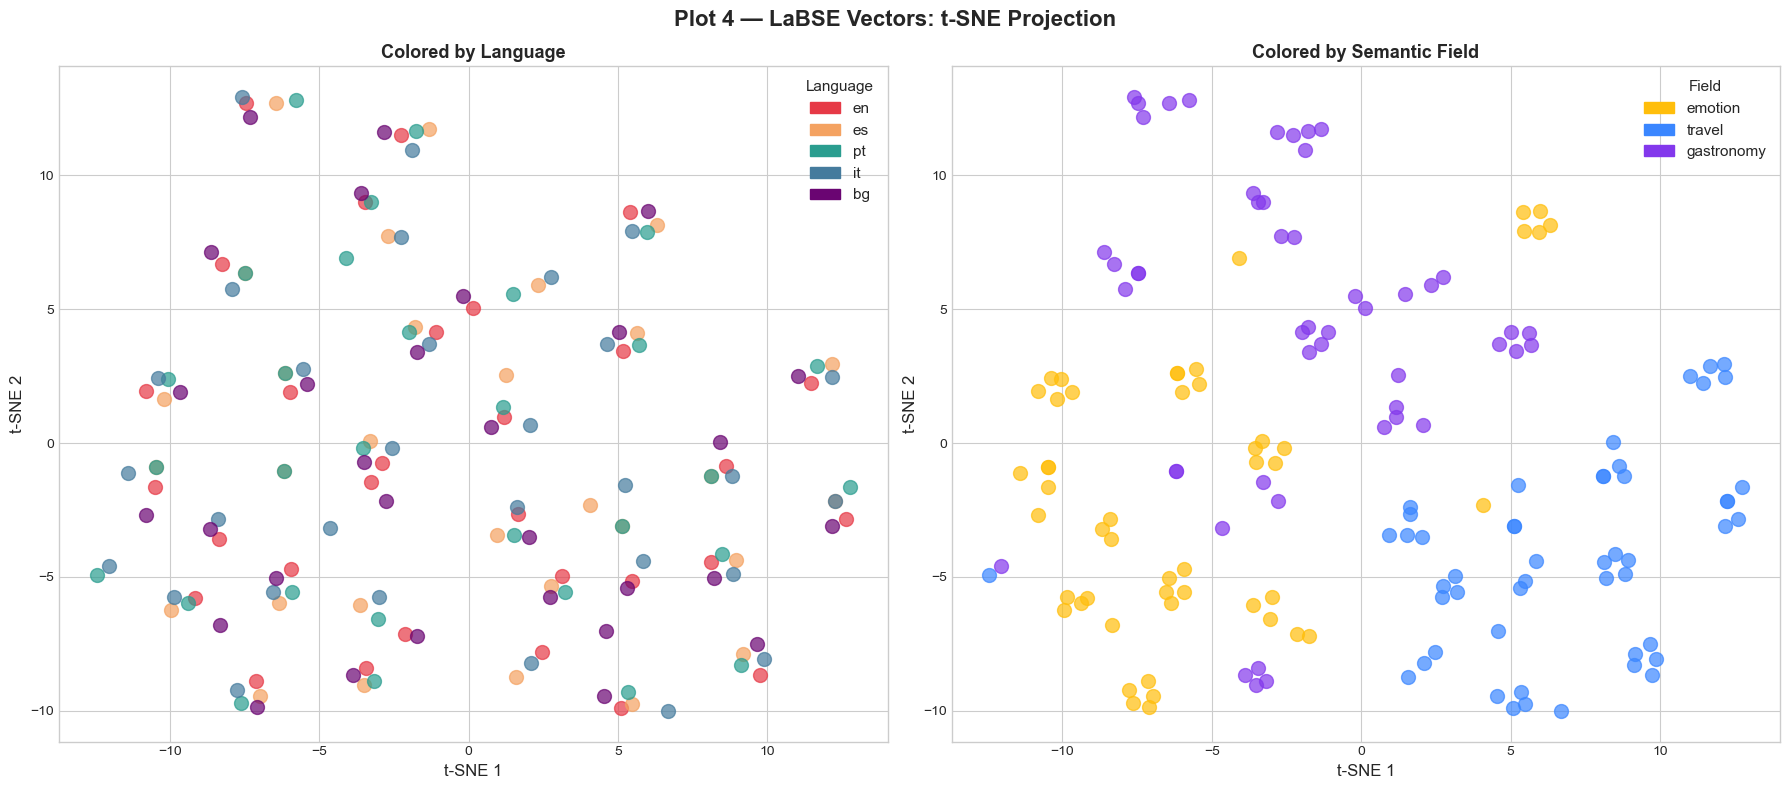

✅ Saved: plot4_labse_tsne.png


In [23]:
# =============================================================
# PLOT 4 — LaBSE t-SNE (colored by language + field)
# =============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Plot 4 — LaBSE Vectors: t-SNE Projection',
             fontsize=16, fontweight='bold')

# Colored by language
ax = axes[0]
for i, (x, y) in enumerate(lb_tsne):
    ax.scatter(x, y, c=lang_colors[lb_languages[i]], alpha=0.7, s=100)
ax.set_title('Colored by Language', fontweight='bold', fontsize=13)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.tick_params(labelsize=10)
lang_patches = [mpatches.Patch(color=c, label=l)
                for l, c in lang_colors.items()]
ax.legend(handles=lang_patches, fontsize=11, title='Language',
          title_fontsize=11)

# Colored by field
ax = axes[1]
for i, (x, y) in enumerate(lb_tsne):
    ax.scatter(x, y, c=field_colors[lb_fields[i]], alpha=0.7, s=100)
ax.set_title('Colored by Semantic Field', fontweight='bold', fontsize=13)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.tick_params(labelsize=10)
field_patches = [mpatches.Patch(color=c, label=f)
                 for f, c in field_colors.items()]
ax.legend(handles=field_patches, fontsize=11, title='Field',
          title_fontsize=11)

plt.tight_layout()
plt.savefig('plot4_labse_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plot4_labse_tsne.png")

# 🌅 Sayonara — Conclusions

*"Not all those who wander are lost."* — J.R.R. Tolkien

But some measurement instruments are.

This project set out to answer a deceptively simple question: 
**can we measure how much meaning is lost in translation?**

The answer is: **yes — but the instrument must be calibrated first.**

## What We Set Out To Do

We designed a computational experiment to measure semantic translation 
loss across five languages — English, Spanish, Portuguese, Italian and 
Bulgarian — using a hand-curated list of 30 concepts spanning emotion, 
travel and gastronomy. We applied three methodologically distinct 
approaches and tested three statistical hypotheses on each.

## What We Found

**Method 1 — Monolingual fastText** produced a Translation Loss metric 
ℒ(c) - an original experimental application of cosine distance - where all 30 concepts clustered between 0.958 and 1.039 — a range 
of only 0.08 around 1.0. Three independent statistical tests confirmed 
this was noise: the mean similarity was statistically indistinguishable 
from zero (p = 0.76), abstraction level showed no significant correlation 
with translation loss (ρ = -0.30, p = 0.11), and our flagship probe — 
cosine_sim(longing_EN, saudade_PT) = 0.037 — suggested these concepts 
share almost no meaning. This was not a failure of the word list. It was 
a failure of the coordinate system.

**Method 3 — LaBSE** applied the same three tests to the same 30 concepts 
in a shared multilingual embedding space. The results reversed completely: 
mean similarity = 0.846 (p = 0.000), *saudade* scored 0.791 — and the 
ranked ℒ(c) table now spans a meaningful range from 0.016 (*love*) to 
0.413 (*wandering*). The instrument, recalibrated, produced signal.

## What This Means

The core finding is precise: **Method 1 measured coordinate distance, 
not semantic distance.** Monolingual fastText models each live in their 
own vector space — English vectors point in directions that have no 
geometric relationship to Spanish vectors, not because the languages 
share no meaning, but because the coordinate systems were never aligned.

LaBSE, trained explicitly to project all languages into a single shared 
space, dissolves this artifact. The four PCA and t-SNE visualizations 
make this visually undeniable — from five isolated language islands to 
one unified semantic landscape.

## What Remains Open

This project measured translation loss at the **word level**. Human 
translation loss operates at the level of context, connotation, and 
cultural resonance — dimensions not captured by single-word embeddings. 
The ranked ℒ(c) table from Method 3 is a starting point, not a final 
answer.

*Wandering* ranks last — most translation loss — not because the word 
is rare, but because its connotations (*vagabundeo*, *erância*, *скитане*) 
carry culturally distinct emotional weights that no coordinate system 
can fully align.

**That is not a limitation of the method. That is the finding.**

## Acknowledgements

This project was designed and executed by **Avgustina Daskalova**, 
MA Applied Linguistics, Sofia University "St. Kliment Ohridski". 
All Bulgarian translations were provided by the author as a native speaker.

AI coding assistance: Claude Sonnet (Anthropic, 2025–2026). All code 
reviewed, tested and validated by the author.

## 🧭 The Compass — Bibliography & Sources

All mathematical concepts, formulas, and tools used in this project are documented
below with their original sources. All sources are open access.

---

### 1. Word Embeddings & The Distributional Hypothesis

**Harris, Z. S. (1954).**
*Distributional Structure.*
Word, 10(2–3), 146–162.
The original paper establishing the Distributional Hypothesis —
*words that appear in similar contexts tend to have similar meanings.*
[https://www.tandfonline.com/doi/abs/10.1080/00437956.1954.11659520](https://www.tandfonline.com/doi/abs/10.1080/00437956.1954.11659520)

**Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013).**
*Efficient Estimation of Word Representations in Vector Space.*
arXiv:1301.3781.
The original Word2Vec paper — foundation of all modern word embeddings.
[https://arxiv.org/abs/1301.3781](https://arxiv.org/abs/1301.3781)

Used for the word vector definition:
$$f: \text{word} \rightarrow \mathbf{v} \in \mathbb{R}^n$$

---

### 2. fastText — Our Embedding Model

**Grave, E., Bojanowski, P., Gupta, P., Joulin, A., & Mikolov, T. (2018).**
*Learning Word Vectors for 157 Languages.*
Proceedings of LREC 2018.
The paper behind the pre-trained models used for all 5 languages.
[https://arxiv.org/abs/1802.06893](https://arxiv.org/abs/1802.06893)

**Bojanowski, P., Grave, E., Joulin, A., & Mikolov, T. (2017).**
*Enriching Word Vectors with Subword Information.*
Transactions of the ACL, 5, 135–146.
Explains why fastText handles Bulgarian morphology better than Word2Vec.
[https://arxiv.org/abs/1607.04606](https://arxiv.org/abs/1607.04606)

**fastText official model download page:**
[https://fasttext.cc/docs/en/crawl-vectors.html](https://fasttext.cc/docs/en/crawl-vectors.html)

---

### 3. Cosine Similarity

**Manning, C. D., Raghavan, P., & Schütze, H. (2008).**
*Introduction to Information Retrieval.*
Cambridge University Press. Chapter 6: Scoring, term weighting, and the vector space model.
Full book freely available online:
[https://nlp.stanford.edu/IR-book/html/htmledition/irbook.html](https://nlp.stanford.edu/IR-book/html/htmledition/irbook.html)

Used for the cosine similarity formula:
$$\text{cos\_sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \cdot \|\mathbf{v}\|}$$

---

### 4. Similarity Matrix & Linear Algebra

**Strang, G. (2016).**
*Introduction to Linear Algebra* (5th ed.).
Wellesley-Cambridge Press.
Foundation for dot products, norms, eigenvectors, and covariance matrices.
[https://math.mit.edu/~gs/linearalgebra/](https://math.mit.edu/~gs/linearalgebra/)

Used for the similarity matrix definition:
$$S_{ij} = \text{cos\_sim}(\mathbf{v}_i, \mathbf{v}_j)$$

and the dot product and Euclidean norm:
$$\mathbf{u} \cdot \mathbf{v} = \sum_{i=1}^{n} u_i v_i, \quad \|\mathbf{u}\| = \sqrt{\sum_{i=1}^{n} u_i^2}$$

**NumPy documentation — Linear Algebra:**
[https://numpy.org/doc/stable/reference/routines.linalg.html](https://numpy.org/doc/stable/reference/routines.linalg.html)

---

### 5. PCA — Principal Component Analysis

**Jolliffe, I. T. (2002).**
*Principal Component Analysis* (2nd ed.).
Springer. The definitive reference for PCA theory.
[https://link.springer.com/book/10.1007/b98835](https://link.springer.com/book/10.1007/b98835)

Used for the PCA formula:
$$X_{\text{reduced}} = X \cdot W, \quad C = \frac{1}{m} X^T X$$

**scikit-learn PCA documentation:**
[https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

---

### 6. t-SNE

**van der Maaten, L., & Hinton, G. (2008).**
*Visualizing Data using t-SNE.*
Journal of Machine Learning Research, 9, 2579–2605.
The original t-SNE paper. Open access.
[https://jmlr.org/papers/v9/vandermaaten08a.html](https://jmlr.org/papers/v9/vandermaaten08a.html)

Used for the KL divergence formulation:
$$KL(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

**scikit-learn t-SNE documentation:**
[https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

---

### 7. Translation Loss Metric

$$\mathcal{L}(c) = 1 - \frac{1}{\binom{k}{2}} \sum_{i < j} \text{cos\_sim}(\mathbf{v}_i^{(c)}, \mathbf{v}_j^{(c)})$$

**This metric is an original formulation by the author** for this project,
inspired by the concept of semantic divergence across languages discussed in:

**Navigli, R., & Ponzetto, S. P. (2012).**
*BabelNet: The automatic construction, evaluation and application of a wide-coverage
multilingual semantic network.*
Artificial Intelligence, 193, 217–250.
[https://doi.org/10.1016/j.artint.2012.07.001](https://doi.org/10.1016/j.artint.2012.07.001)

---

### 8. Language Families

**Ethnologue: Languages of the World.**
SIL International. Reference for Indo-European language family classification.
[https://www.ethnologue.com](https://www.ethnologue.com)

**Glottolog 4.8 (2023).**
Max Planck Institute for Evolutionary Anthropology.
Open-access language family database.
[https://glottolog.org](https://glottolog.org)

---

### 9. Python Libraries & Environment

| Tool | Reference | Link |
|------|-----------|------|
| `anaconda` | Anaconda Inc. (2020). *Anaconda Software Distribution*. | [https://www.anaconda.com](https://www.anaconda.com) |
| `jupyterlab` | Kluyver et al. (2016). *Jupyter Notebooks — a publishing format for reproducible computational science*. IOS Press. | [https://eprints.soton.ac.uk/403913/](https://eprints.soton.ac.uk/403913/) |
| `numpy` | Harris et al. (2020). *Array programming with NumPy*. Nature, 585, 357–362. | [https://doi.org/10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2) |
| `pandas` | McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proc. SciPy 2010. | [https://pandas.pydata.org](https://pandas.pydata.org) |
| `scikit-learn` | Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825–2830. | [https://jmlr.org/papers/v12/pedregosa11a.html](https://jmlr.org/papers/v12/pedregosa11a.html) |
| `matplotlib` | Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. CiSE, 9(3), 90–95. | [https://doi.org/10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55) |
| `seaborn` | Waskom, M. (2021). *seaborn: statistical data visualization*. JOSS, 6(60). | [https://doi.org/10.21105/joss.03021](https://doi.org/10.21105/joss.03021) |
| `gensim` | Řehůřek & Sojka (2010). *Software Framework for Topic Modelling with Large Corpora*. | [https://radimrehurek.com/gensim/](https://radimrehurek.com/gensim/) |
| `fasttext` | Grave et al. (2018) — see Section 2 above. | [https://fasttext.cc](https://fasttext.cc) |

*All sources accessed April 2026. All links verified at time of writing.*

---